In [42]:
import os
import torch
from torch import nn
from d2l import torch as d2l

In [38]:
#1. Download and preprocess the English-French dataset
class MTFraEng(d2l.DataModule): #@save
    """The English French Dataset"""

    def __init__(self, batch_size, num_steps=9, num_train=512, num_val=128):
        super(MTFraEng, self).__init__()
        self.save_hyperparameters()
        self.arrays, self.src_vocab, self.tgt_vocab = self._build_arrays(self._download())

    #1. Download the data
    def _download(self):
        d2l.extract(d2l.download(
            d2l.DATA_URL+'fra-eng.zip', self.root,
            '94646ad1522d915e7b0f9296181140edcf86a4f5'))
        with open(self.root + '/fra-eng/fra.txt', encoding='utf-8') as f:
            return f.read()
        
    #2. Pre Process  
    def _preprocess(self, text):
        # Replace non-breaking space with space
        text = text.replace('\u202f', ' ').replace('\xa0', ' ')
        # Insert space between words and punctuation marks
        no_space = lambda char, prev_char: char in ',.!?' and prev_char != ' '
        out = [' ' + char if i > 0 and no_space(char, text[i - 1]) else char
            for i, char in enumerate(text.lower())]
        return ''.join(out)
    
    #3. Tokenize the data
    def _tokenize(self, text, max_examples=None):
        src, tgt = [], []
        for i, line in enumerate(text.split('\n')):
            if max_examples and i > max_examples: break

            parts = line.split('\t')
            if len(parts) == 2:
                src.append([t for t in f'{parts[0]} <eos>'.split(' ') if t]) #append <eos> token
                tgt.append([t for t in f'{parts[1]} <eos>'.split(' ') if t]) #append <eos> token
        
        return src, tgt

    #4. Build Source and Target Vocabulary
    def _build_arrays(self, raw_text, src_vocab=None, tgt_vocab=None):
        def _build_array(sentences, vocab, is_tgt=False):

            #pad or trim to the specified length of num_steps
            pad_or_trim = lambda seq, t: (
                seq[:t] if len(seq) > t else seq + ['<pad>']*(t-len(seq)))
            sentences = [pad_or_trim(s, self.num_steps) for s in sentences]

            if is_tgt:
                sentences = [['<bos>'] + s for s in sentences]
            if vocab is None:
                vocab = d2l.Vocab(sentences, min_freq=2)
            array = torch.tensor([vocab[s] for s in sentences])

            valid_len = (array != vocab['<pad>']).type(torch.int32).sum(1) #Determine the valid length without padding
            return array, vocab, valid_len
        
        src, tgt = self._tokenize(self._preprocess(raw_text), self.num_train + self.num_val)
        src_array, src_vocab, src_valid_len = _build_array(src, src_vocab)
        tgt_array, tgt_vocab, tgt_valid_len = _build_array(tgt, tgt_vocab, True)

        return ((src_array, tgt_array[:,:-1], src_valid_len, tgt_array[:,1:]), src_vocab, tgt_vocab)
    
    def get_dataloader(self, train):
        idx = slice(0, self.num_train) if train else slice(self.num_train, None)
        return self.get_tensorloader(self.arrays, train, idx)

    def build(self, src_sentences, tgt_sentences):
        raw_text = '\n'.join([src + '\t' + tgt for src, tgt in zip(src_sentences, tgt_sentences)])
        arrays, _, _ = self._build_arrays(raw_text, self.src_vocab, self.tgt_vocab)
        return arrays


In [33]:
data = MTFraEng(batch_size=6)
raw_text = data._download()
print(raw_text[:75])

Go.	Va !
Hi.	Salut !
Run!	Cours !
Run!	Courez !
Who?	Qui ?
Wow!	Ça alors !



In [34]:
src, tgt = data._tokenize(raw_text)
src[:6], tgt[:6]

([['Go.', '<eos>'],
  ['Hi.', '<eos>'],
  ['Run!', '<eos>'],
  ['Run!', '<eos>'],
  ['Who?', '<eos>'],
  ['Wow!', '<eos>']],
 [['Va', '!', '<eos>'],
  ['Salut', '!', '<eos>'],
  ['Cours\u202f!', '<eos>'],
  ['Courez\u202f!', '<eos>'],
  ['Qui', '?', '<eos>'],
  ['Ça', 'alors\u202f!', '<eos>']])

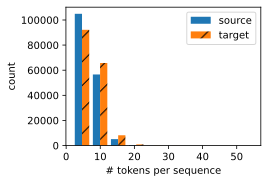

In [35]:
#@save
def show_list_len_pair_hist(legend, xlabel, ylabel, xlist, ylist):
    """Plot the histogram for list length pairs."""
    d2l.set_figsize()
    _, _, patches = d2l.plt.hist(
        [[len(l) for l in xlist], [len(l) for l in ylist]])
    d2l.plt.xlabel(xlabel)
    d2l.plt.ylabel(ylabel)
    for patch in patches[1].patches:
        patch.set_hatch('/')
    d2l.plt.legend(legend)

show_list_len_pair_hist(['source', 'target'], '# tokens per sequence',
                        'count', src, tgt);

In [39]:
data = MTFraEng(batch_size=3)
src, tgt, src_valid_len, label = next(iter(data.train_dataloader()))
print('source:', src.type(torch.int32))
print('decoder input:', tgt.type(torch.int32))
print('source len excluding pad:', src_valid_len.type(torch.int32))
print('label:', label.type(torch.int32))

source: tensor([[183,   8,   2,   3,   4,   4,   4,   4,   4],
        [ 28,  70,   2,   3,   4,   4,   4,   4,   4],
        [ 84, 139,  91,   2,   3,   4,   4,   4,   4]], dtype=torch.int32)
decoder input: tensor([[  3, 135,   6,   6,   2,   4,   5,   5,   5],
        [  3, 204,   6,   2,   4,   5,   5,   5,   5],
        [  3, 108, 112, 208,   2,   4,   5,   5,   5]], dtype=torch.int32)
source len excluding pad: tensor([4, 4, 5], dtype=torch.int32)
label: tensor([[135,   6,   6,   2,   4,   5,   5,   5,   5],
        [204,   6,   2,   4,   5,   5,   5,   5,   5],
        [108, 112, 208,   2,   4,   5,   5,   5,   5]], dtype=torch.int32)


In [40]:
src, tgt, _, _ = data.build(['hi.'], ['salut.'])
print('source:', data.src_vocab.to_tokens(src[0].type(torch.int32)))
print('target:', data.tgt_vocab.to_tokens(tgt[0].type(torch.int32)))

source: ['hi', '.', '<eos>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>']
target: ['<bos>', 'salut', '.', '<eos>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>']


Machine translation takes a sequence as input and generates a sequence in another language as output. The input and output need not be of the same length. i.e. Sequence is input and sequence is output. Such models are called Sequence-2-Sequence models. 

The architecture for such situation is encoder-decoder architecture. It has two components
1. Encoder - Takes variable length sequence as input
2. Decoder - Acts as conditional language model, taking in the encoded input and the leftwards context of the target sequence and predicting the subsequent token in the target sequence.

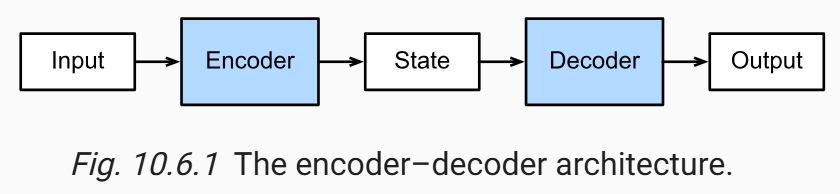

In [43]:
class Encoder(nn.Module): #@save
    """The base encoder interface for encoder-decoder architecture"""

    def __init__(self):
        super().__init__()

    def forward(self, X, *args):
        raise NotImplementedError

In [44]:
class Decoder(nn.Module):  #@save
    """The base decoder interface for the encoder--decoder architecture."""
    def __init__(self):
        super().__init__()

    # Later there can be additional arguments (e.g., length excluding padding)
    def init_state(self, enc_all_outputs, *args):
        raise NotImplementedError

    def forward(self, X, state):
        raise NotImplementedError

In [45]:
class EncoderDecoder(d2l.Classifier):  #@save
    """The base class for the encoder--decoder architecture."""
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, enc_X, dec_X, *args):
        enc_all_outputs = self.encoder(enc_X, *args)
        dec_state = self.decoder.init_state(enc_all_outputs, *args)
        # Return decoder output only
        return self.decoder(dec_X, dec_state)[0]